In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación de datos y optimización
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modelos (Regresión y Clasificación)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Métricas de evaluación
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

**Clasificación vs Regresión (Elección del modelo)**
Objetivo del taller
Aplicar un flujo básico de Machine Learning para resolver un problema real, identificando correctamente si se trata de regresión o clasificación, construyendo un modelo predictivo y evaluando su desempeño

DATASETS
Elije unos de los dos:
Dataset 1: Predicción de precio de un carro
    • https://www.kaggle.com/datasets/hellbuoy/car-price-prediction
Objetivo del negocio: estimar el precio de un vehículo basado en sus características.

Dataset 2: Predicción de aprobación de préstamos
    • https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
Objetivo del negocio: predecir si una solicitud de crédito será aprobada o no.

**Identifica la variable objetivo (target) **

**Responde: **

 **¿Es un problema de clasificación o regresión?**

  Este es un problema de clasificacion

 **¿Por qué?**
  por que la base de datos las puedo clasificar por etiquetas descriptivas y me permite al modelo poder indentificar quienes se le aprueban al credito y a quienes no, por que ya tengo una clasificacion en los datos

**Describe brevemente el contexto del problema**

El problema es poder indentificar que clientes tiene mas posibilidades de aprobacion del credito

In [ ]:
from google.colab import files
uloaded =files.upload()

Saving train_credito .csv to train_credito  (2).csv


In [ ]:
df = pd.read_csv('train_credito .csv')
df.head(20
        )

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
#esploracion de los datos
df.info()
#Informacion de columnas y filas
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


(614, 13)

In [ ]:
pd.isnull(df).sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df. describe(include="all")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [ ]:
#Tipo de datos
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
#Datos duplicados
df.duplicated().sum() #datos duplicados

np.int64(0)

# **Limpieza de datos**

In [ ]:
#Duplicar base de datos
df_copia = df.copy()

In [ ]:
#1. Rellenar campos vacios
df_copia['Gender'] = df_copia['Gender'].replace("", None)
df_copia['Dependents'] = df_copia['Dependents'].replace("", None)
df_copia['Self_Employed'] = df_copia['Self_Employed'].replace("", None)

# 2. Calculamos la media de la columna
media_loan_amount = df_copia['LoanAmount'].mean()
media_loan_term = df_copia['Loan_Amount_Term'].mean()

# 3. Rellenamos los nulos
df_copia['LoanAmount'] = df_copia['LoanAmount'].fillna(media_loan_amount)
df_copia['Loan_Amount_Term'] = df_copia['Loan_Amount_Term'].fillna(media_loan_term)

# 5. Rellenar historial crediticio (el valor más frecuente es 1.0)
df_copia['Credit_History'] = df_copia['Credit_History'].fillna(1.0)


In [ ]:
df_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
pd.isnull(df_copia).sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df_copia= df_copia.reset_index(drop=True)

In [ ]:
#verificar si tengo outlier
df_copia.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.000000,0.855049
std,6109.041673,2926.248369,84.037468,64.372489,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,129.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [ ]:
# Aplicar logaritmo para suavizar la distribución de los outliers
df_copia['ApplicantIncome'] = np.log1p(df_copia['ApplicantIncome'])
df_copia['CoapplicantIncome'] = np.log1p(df_copia['CoapplicantIncome'])
df_copia['LoanAmount'] = np.log1p(df_copia['LoanAmount'])



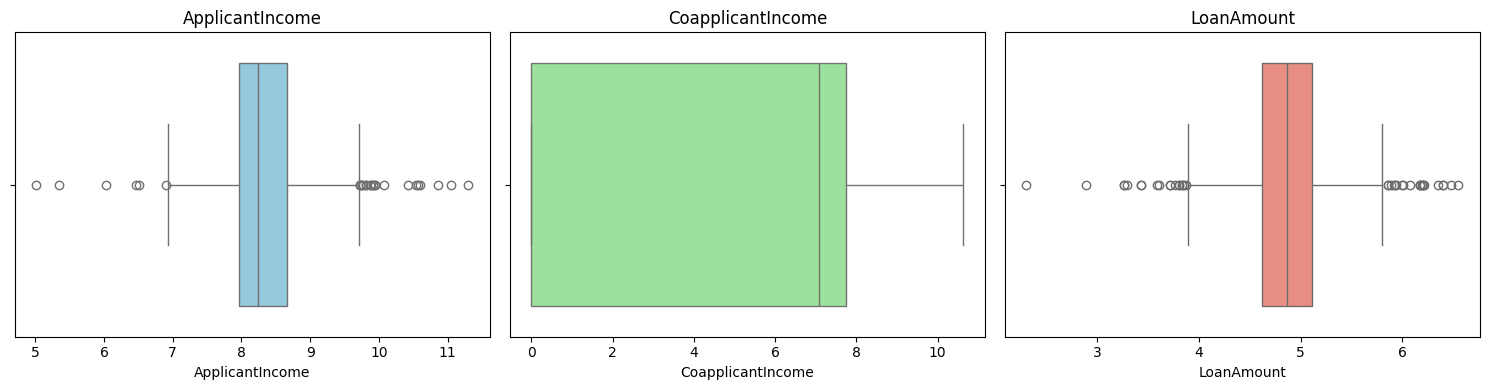

In [ ]:
# Creamos una ventana para los 3 nuevos gráficos normalizados
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Gráfico logarítmico para Ingresos del solicitante
sns.boxplot(ax=axes[0], x=df_copia['ApplicantIncome'], color='skyblue')
axes[0].set_title('ApplicantIncome')

# 2. Gráfico logarítmico para Ingresos del co-solicitante
sns.boxplot(ax=axes[1], x=df_copia['CoapplicantIncome'], color='lightgreen')
axes[1].set_title('CoapplicantIncome')

# 3. Gráfico logarítmico para Monto del préstamo
sns.boxplot(ax=axes[2], x=df_copia['LoanAmount'], color='salmon')
axes[2].set_title('LoanAmount')

plt.tight_layout()
plt.show()

In [ ]:
df_copia.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,8.341510,4.290129,4.870872,342.000000,0.855049
std,0.645035,3.875873,0.491376,64.372489,0.352339
min,5.017280,0.000000,2.302585,12.000000,0.000000
25%,7.965024,0.000000,4.617584,360.000000,1.000000
50%,8.246303,7.081125,4.867534,360.000000,1.000000
75%,8.664922,7.739897,5.110477,360.000000,1.000000
max,11.302217,10.637489,6.552508,480.000000,1.000000


# **Machine Learning**

In [ ]:
# Eliminar ID
df_copia.drop("Loan_ID", axis=1, inplace=True, errors='ignore')

In [ ]:
df_copia.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,8.674197,0.000000,4.993232,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,8.430327,7.319202,4.859812,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,8.006701,0.000000,4.204693,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,7.857094,7.765993,4.795791,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,8.699681,0.000000,4.955827,360.0,1.0,Urban,Y


In [ ]:
# 1. Convertir todas las variables categóricas a números (Dummies)
df_procesado = pd.get_dummies(df_copia, drop_first=True)

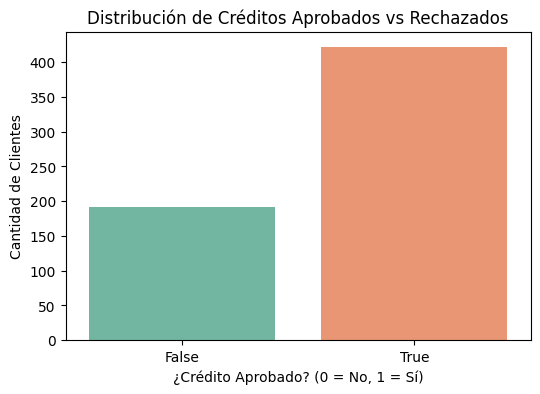

In [ ]:
# Gráfico 1: Conteo de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x=df_procesado['Loan_Status_Y'], hue=df_procesado['Loan_Status_Y'], palette='Set2', legend=False)
plt.title('Distribución de Créditos Aprobados vs Rechazados')
plt.xlabel('¿Crédito Aprobado? (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.show()

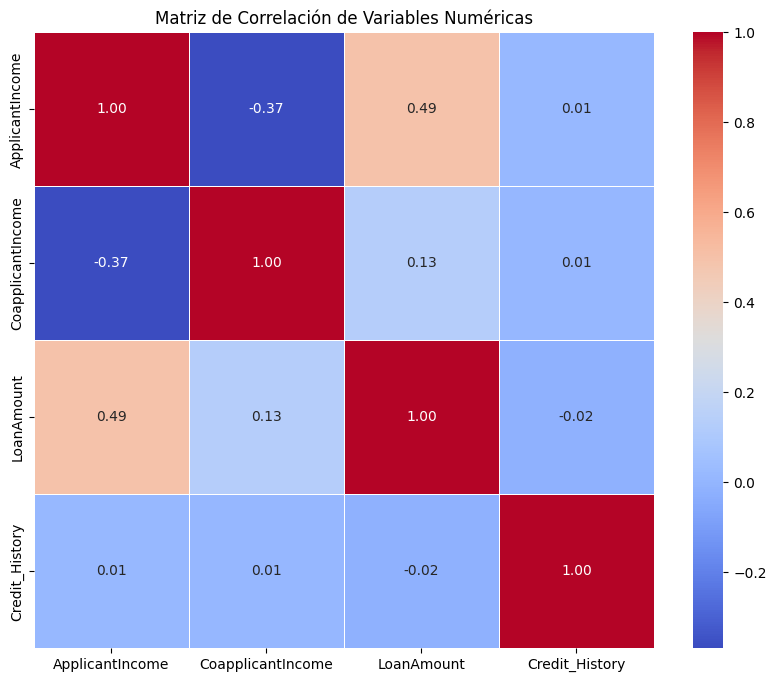

In [ ]:
# Gráfico 2: Matriz de correlación numérica
plt.figure(figsize=(10, 8))
corr_matrix = df_procesado[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [ ]:
# sacara grafico barras para analalizar para identificar cual son los factores cual son las variables /barra

In [ ]:
#2. Separar mis variables
X = df_procesado.drop(columns=['Loan_Status_Y'])
y = df_procesado['Loan_Status_Y']

In [ ]:
# 3. División de los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.info()
X_test.info()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 154 to 354
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ApplicantIncome          491 non-null    float64
 1   CoapplicantIncome        491 non-null    float64
 2   LoanAmount               491 non-null    float64
 3   Loan_Amount_Term         491 non-null    float64
 4   Credit_History           491 non-null    float64
 5   Gender_Male              491 non-null    bool   
 6   Married_Yes              491 non-null    bool   
 7   Dependents_1             491 non-null    bool   
 8   Dependents_2             491 non-null    bool   
 9   Dependents_3+            491 non-null    bool   
 10  Education_Not Graduate   491 non-null    bool   
 11  Self_Employed_Yes        491 non-null    bool   
 12  Property_Area_Semiurban  491 non-null    bool   
 13  Property_Area_Urban      491 non-null    bool   
dtypes: bool(9), float64(5)
memory

In [ ]:
#Entrenar el modelo
#Regresion logistica
log_reg = LogisticRegression(max_iter=1000) #se usa 1000 inteaciones para la convergencia
log_reg.fit(X_train, y_train)#aprendemos el modelo de los datos de entrenamiento
y_pred = log_reg.predict(X_test)#tomar el modelo aprendido y predecir lo datos de prueba

In [ ]:
matriz_confusion =confusion_matrix(y_test, y_pred)

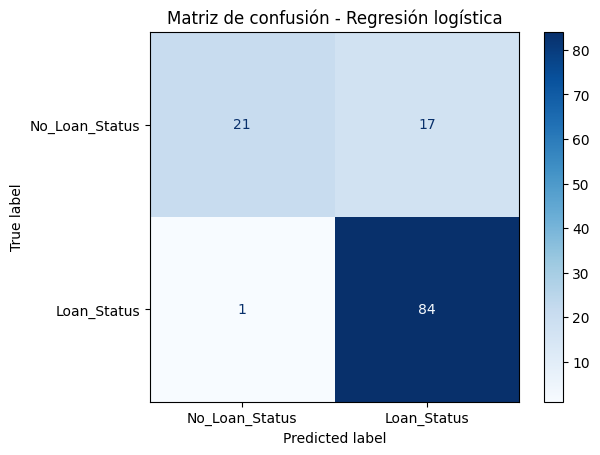

0.8536585365853658
[[21 17]
 [ 1 84]]
              precision    recall  f1-score   support

       False       0.95      0.55      0.70        38
        True       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [ ]:
mapa_calor = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['No_Loan_Status','Loan_Status'])
mapa_calor.plot(cmap='Blues')
plt.title('Matriz de confusión - Regresión logística')
plt.show()
print(accuracy_score(y_test, y_pred))
print(matriz_confusion)
print(classification_report(y_test, y_pred))

In [ ]:
# Árbol de decision

arbol = DecisionTreeClassifier(max_depth=5) # Limita la profundidad del árbol (se construye con 5 arboles)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test) # Toma el modelo y predice los datos

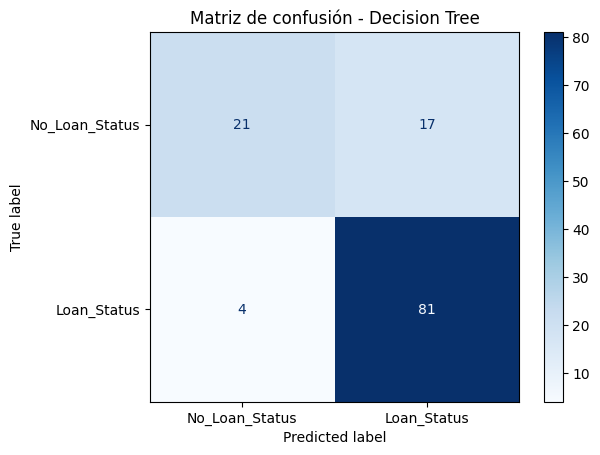

--- Accuracy Score ---
0.8292682926829268

--- Matriz de Confusión (Texto) ---
[[21 17]
 [ 4 81]]

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       False       0.84      0.55      0.67        38
        True       0.83      0.95      0.89        85

    accuracy                           0.83       123
   macro avg       0.83      0.75      0.78       123
weighted avg       0.83      0.83      0.82       123



In [ ]:
# 1. Calcular la matriz de confusión
matriz_confusion_arbol = confusion_matrix(y_test, y_pred_arbol)

# 2. Configurar y graficar el mapa de calor con las etiquetas correctas
mapa_calor = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_arbol, display_labels=['No_Loan_Status', 'Loan_Status'])
mapa_calor.plot(cmap='Blues')
plt.title('Matriz de confusión - Decision Tree')
plt.show()

# 3. Imprimir las métricas de evaluación
print("--- Accuracy Score ---")
print(accuracy_score(y_test, y_pred_arbol))

print("\n--- Matriz de Confusión (Texto) ---")
print(matriz_confusion_arbol)

print("\n--- Reporte de Clasificación ---")
# Línea corregida con el doble paréntesis al final ))
print(classification_report(y_test, y_pred_arbol))

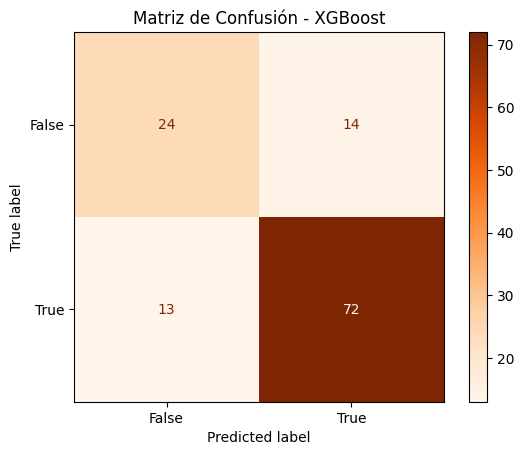

In [ ]:
import xgboost as xgb

# 1. Instanciar y entrenar el modelo XGBoost
model_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

# 2. Hacer predicciones
y_pred_xgb = model_xgb.predict(X_test)

# 3. Graficar la Matriz de Confusión
ConfusionMatrixDisplay.from_estimator(model_xgb, X_test, y_test, cmap='Oranges')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

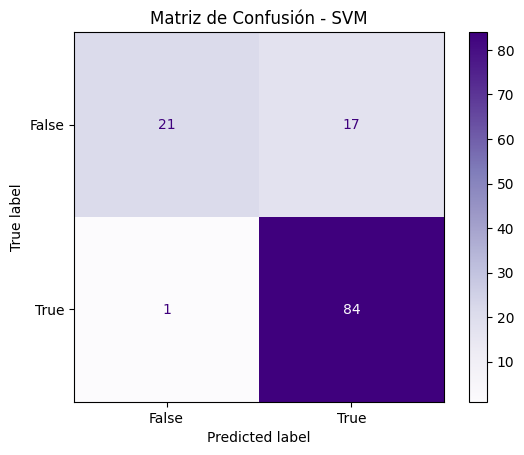

In [ ]:
from sklearn.svm import SVC

# 1. Instanciar y entrenar el modelo SVM
model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(X_train, y_train)

# 2. Hacer predicciones
y_pred_svm = model_svm.predict(X_test)

# 3. Graficar la Matriz de Confusión
ConfusionMatrixDisplay.from_estimator(model_svm, X_test, y_test, cmap='Purples')
plt.title('Matriz de Confusión - SVM')
plt.show()

**Parte 6 – Interpretación**
**Responder:**
    
**¿Qué tan bueno es el modelo? **
El modelo de regresion es el mejor debido a que su precision

**¿Qué variable parece influir más en la predicción?**

las variables como se pueden evidenciar en mi matriz de correlacion se evidencia que ApplicantIncome y LoanAmount son los que tienen mas influencia patra la aprobacion del credito

**¿Qué mejorarías si tuvieras más tiempo?**

si tuviera mas tiempos podria analizar otras variables diferente para analizar si esto me influye en las aprobaciones